# Real-Time Webcam Emotion Detection Dashboard Using ResNet18 Fine-Tuned on FER2013

## Phase 4B: Model Improvement and Tuning

This notebook builds on the baseline ResNet18 training notebook and tries to improve performance on the FER2013 subset.

Goals for this notebook:
- train longer than the baseline
- use stronger data augmentation
- handle class imbalance with class weights
- save the best model using validation accuracy
- evaluate the tuned model on the test set

This notebook does **not** build webcam inference or the dashboard.

## 1. Project Setup and Imports

We import the core libraries for PyTorch training, plotting, and evaluation.

In [1]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm


## 2. CUDA / GPU Check

We use CUDA automatically if it is available and set a fixed random seed for reproducibility.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Using device: cuda
NVIDIA GeForce RTX 3060 Laptop GPU


## 3. Dataset Paths and Class Names

We reuse the processed FER2013 subset created earlier.

Class names:
- angry
- disgust
- fear
- happy
- sad
- surprise
- neutral

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "fer2013_subset"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODEL_PATH = MODELS_DIR / "resnet18_fer2013_tuned.pth"
TRAINING_CURVES_PATH = OUTPUTS_DIR / "training_curves_tuned.png"
CONFUSION_MATRIX_PATH = OUTPUTS_DIR / "confusion_matrix_tuned.png"
CLASSIFICATION_REPORT_PATH = OUTPUTS_DIR / "classification_report_tuned.txt"

EXPECTED_CLASSES = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

for path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, path.exists())

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\data\processed\fer2013_subset\train True
C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\data\processed\fer2013_subset\val True
C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\data\processed\fer2013_subset\test True


## 4. Stronger Image Transforms

FER2013 images are grayscale and small, so we convert them to 3 channels and resize to `224 x 224` for ResNet18.

Compared with the baseline, we add stronger training augmentation:
- random horizontal flip
- small rotation
- slight affine transform
- small color jitter after converting to 3 channels

Validation and test transforms stay simple and consistent.

In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


## 5. Load Train, Val, and Test Datasets

We again use `ImageFolder` so the class folders define the labels automatically.

In [5]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("ImageFolder class order:", class_names)
print("Expected class set matches:", set(class_names) == set(EXPECTED_CLASSES))
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


ImageFolder class order: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Expected class set matches: True
Train size: 5470
Val size: 966
Test size: 5900


In [6]:
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


## 6. Inspect Class Imbalance and Build Class Weights

Some classes in FER2013 have fewer images than others. To help the model pay more attention to underrepresented classes, we compute class weights and pass them to `CrossEntropyLoss`.

In [7]:
train_targets = np.array(train_dataset.targets)
class_counts = np.bincount(train_targets, minlength=num_classes)
class_weights = len(train_targets) / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

for class_name, count, weight in zip(class_names, class_counts, class_weights):
    print(f"{class_name:>8} | count = {count:4d} | weight = {weight:.4f}")


   angry | count =  850 | weight = 0.9193
 disgust | count =  370 | weight = 2.1120
    fear | count =  850 | weight = 0.9193
   happy | count =  850 | weight = 0.9193
 neutral | count =  850 | weight = 0.9193
     sad | count =  850 | weight = 0.9193
surprise | count =  850 | weight = 0.9193


## 7. Show a Few Sample Images with Labels

This gives a quick visual check of the augmented training pipeline.

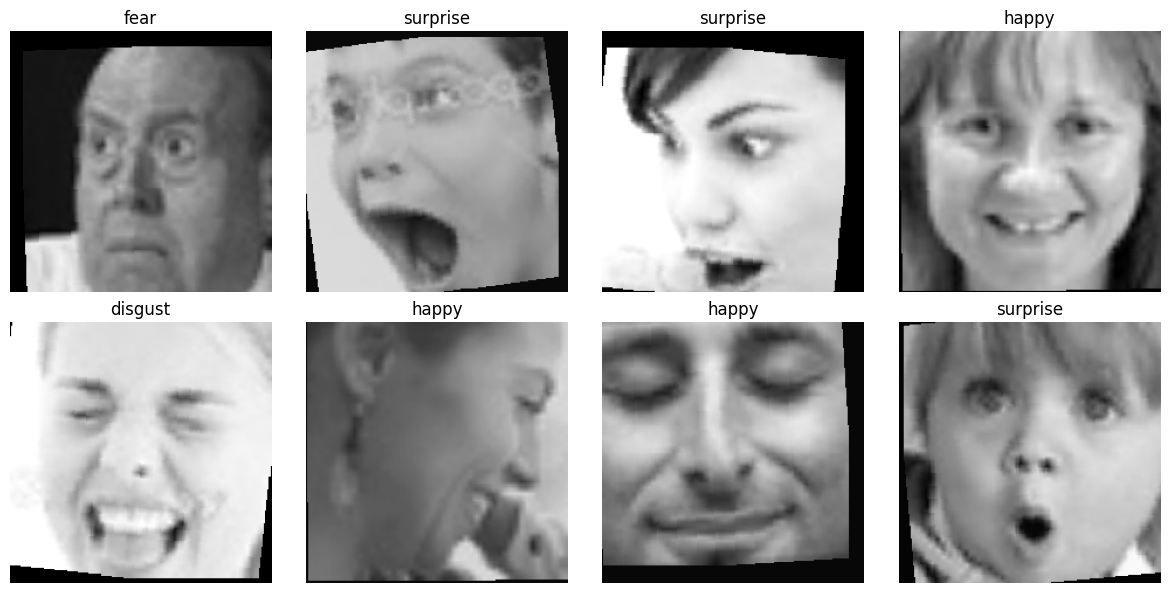

In [8]:
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = image_tensor.cpu() * std + mean
    return image_tensor.clamp(0, 1)

sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for idx in range(8):
    image = denormalize(sample_images[idx]).permute(1, 2, 0).numpy()
    label = class_names[sample_labels[idx].item()]
    axes[idx].imshow(image)
    axes[idx].set_title(label)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## 8. Load Pretrained ResNet18

We use pretrained ImageNet weights and replace the final layer for 7 FER2013 classes.

In [9]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

print(model.fc)


Linear(in_features=512, out_features=7, bias=True)


## 9. Define Loss Function, Optimizer, and Training Settings

Tuning changes in this notebook:
- `10` epochs instead of `3`
- learning rate `1e-4`
- class-weighted cross-entropy loss
- best model saved using validation accuracy

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_training):
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (preds == labels).sum().item()
            total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = running_correct / total_samples
    return epoch_loss, epoch_accuracy


## 10. Train the Tuned Model for 10 Epochs

We keep the best model weights using validation accuracy.

In [11]:
best_model_wts = copy.deepcopy(model.state_dict())
best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_accuracy = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(f"  Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


Epoch 1/10


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  Train Loss: 1.5397 | Train Accuracy: 0.4168
  Val Loss:   1.2666 | Val Accuracy:   0.5145
Epoch 2/10


  0%|          | 0/171 [00:00<?, ?it/s]

...

  0%|          | 0/31 [00:00<?, ?it/s]

  Train Loss: 0.4267 | Train Accuracy: 0.8441
  Val Loss:   1.3452 | Val Accuracy:   0.5932
Epoch 10/10


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  Train Loss: 0.3588 | Train Accuracy: 0.8724
  Val Loss:   1.2901 | Val Accuracy:   0.5983
Best validation accuracy: 0.5983


## 11. Training History

We track the same four metrics as before:
- train loss
- train accuracy
- validation loss
- validation accuracy

In [12]:
history


{'train_loss': [1.5397356366762514,
  1.1552968007337023,
  1.0018025759587121,
  0.8665427095493408,
  0.7610493787790783,
  0.6705748601195145,
  0.5832995581888412,
  0.48710865126667335,
  0.42671200973024315,
  0.3587531853637486],
 'train_accuracy': [0.41681901279707495,
  0.5608775137111517,
  0.6155393053016454,
  0.673126142595978,
  0.7073126142595978,
  0.7455210237659964,
  0.7817184643510054,
  0.816636197440585,
  0.8440585009140767,
  0.8723948811700183],
 'val_loss': [1.2665766482521041,
  1.1632375193925624,
  1.1211655207795879,
  1.1886384440258175,
  1.137675230300698,
  1.2533008584571428,
  1.2057740430407395,
  1.2265570920199835,
  1.3452068767809227,
  1.2900635349577751],
 'val_accuracy': [0.5144927536231884,
  0.5445134575569358,
  0.582815734989648,
  0.5693581780538303,
  0.5921325051759835,
  0.587991718426501,
  0.5900621118012422,
  0.577639751552795,
  0.593167701863354,
  0.598343685300207]}

## 12. Plot Training Curves

We save the tuned training curves to the `outputs/` folder with a different filename from the baseline notebook.

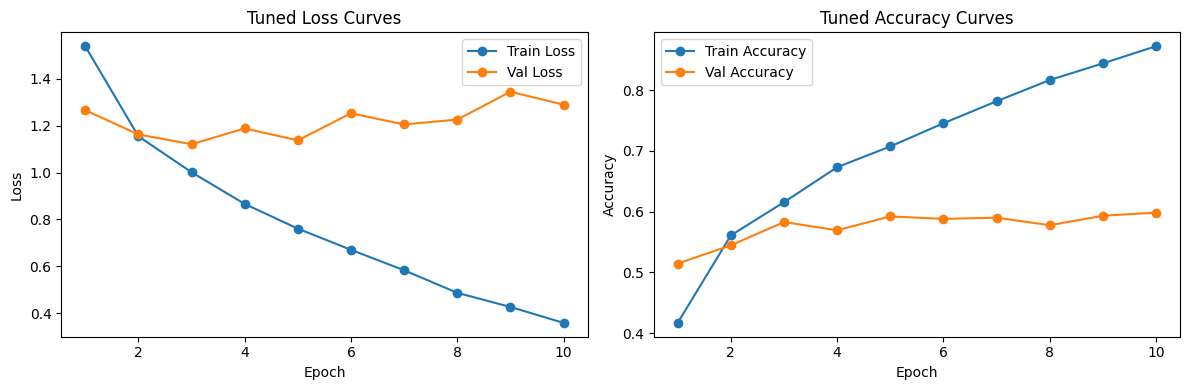

Saved training curves to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\outputs\training_curves_tuned.png


In [13]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Tuned Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_accuracy"], marker="o", label="Train Accuracy")
axes[1].plot(epochs_range, history["val_accuracy"], marker="o", label="Val Accuracy")
axes[1].set_title("Tuned Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRAINING_CURVES_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved training curves to: {TRAINING_CURVES_PATH}")


## 13. Evaluate on the Test Set

We evaluate the tuned model using the best validation checkpoint.

In [14]:
model.eval()

all_preds = []
all_labels = []
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(dim=1)

        batch_size = labels.size(0)
        test_loss += loss.item() * batch_size
        test_correct += (preds == labels).sum().item()
        test_total += batch_size

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


  0%|          | 0/185 [00:00<?, ?it/s]

Test Loss: 1.4082
Test Accuracy: 0.5753


## 14. Confusion Matrix and Classification Report

We create and save tuned evaluation artifacts with separate filenames.

              precision    recall  f1-score   support

       angry       0.51      0.53      0.52       958
     disgust       0.40      0.77      0.52       111
        fear       0.44      0.44      0.44      1000
       happy       0.82      0.76      0.79      1000
     neutral       0.57      0.59      0.58      1000
         sad       0.45      0.46      0.46      1000
    surprise       0.76      0.67      0.71       831

    accuracy                           0.58      5900
   macro avg       0.56      0.60      0.57      5900
weighted avg       0.58      0.58      0.58      5900



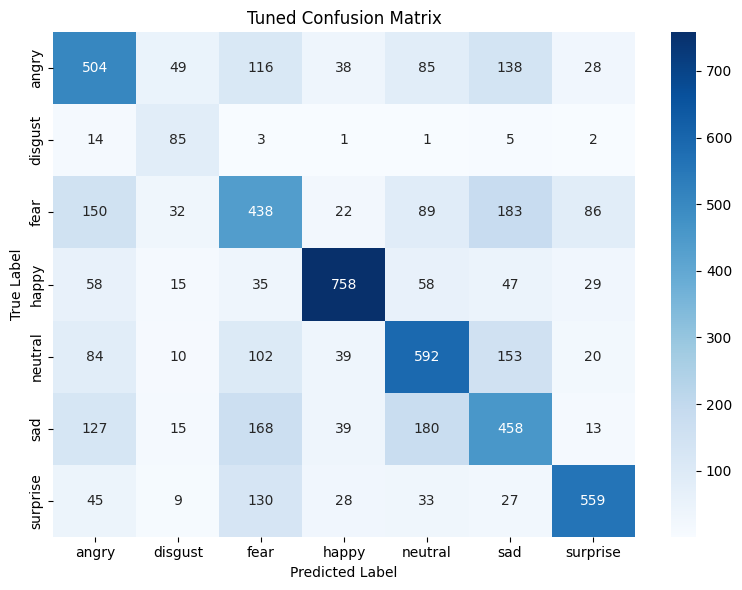

Saved confusion matrix to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\outputs\confusion_matrix_tuned.png
Saved classification report to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\outputs\classification_report_tuned.txt


In [15]:
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

with open(CLASSIFICATION_REPORT_PATH, "w", encoding="utf-8") as file:
    file.write(report)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Tuned Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix to: {CONFUSION_MATRIX_PATH}")
print(f"Saved classification report to: {CLASSIFICATION_REPORT_PATH}")


## 15. Save the Tuned Model

We save the best tuned model weights to a new file so the baseline model remains untouched.

In [16]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved tuned model to: {MODEL_PATH}")


Saved tuned model to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\models\resnet18_fer2013_tuned.pth


## 16. Output Summary

Expected saved outputs after running the full notebook:
- `models/resnet18_fer2013_tuned.pth`
- `outputs/training_curves_tuned.png`
- `outputs/confusion_matrix_tuned.png`
- `outputs/classification_report_tuned.txt`